# Benchmarking the MLE algorithm

We run the algorithm for different target states with the parameters:
- fock_cutoff: 50
- x_array: range = (-5,5), num_points=1000
- default number of angles, samples: (4,1000)
- default number of bins: 20
- Convergence criterion: fidelity to previous iteration > 0.99999
- Maximum amount of iterations permitted: 1000
- Reproducibility seed: 12345
- Each simulation ran 20 times
- Initial guess state: Vacuum $\ket{0}$

The algorithm is run until it converges and we recorded:
- Fidelity of reconstructed state with respect to the target
- Number of iterations needed to converge

We show in plots how the algorithm is affected by changes in:
- Number of bins
- Changes of samples: measurement angles and samples per angle

The main takeaways are:
- Binsize (/Number of bins): 
Depending on the fine features of the state, there is a minimal amount of number of bins needed to reconstruct the state fatefully. For less bins the algorithm converges to a state, that does not have the fine features and is in general quite different from the actual state. For more bins above this threshold number, increasing does not help in the reconstruction fidelity, but might lead to a smaller number of iterations needed for convergence.

For our data 20 bins (0.5 resolution) is enough for obtaining faithfull reconstruction

- Sample size: 
Increasing the number of samples per angle similarly to the finer binning, makes the reconstruction faster and better, the effect is small for the considered states in the 100-1000 range here. For states with phase dependence capturing data from more angles captures these features better.

For our data having 8 angles and 500 samples per angle reconstructs the states in close to minimal iterations and close to maximal fidelity.

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

import qutip as q

import h5py

import sys
from pathlib import Path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
 
# Load h5 file with benchmark results
results_20runs = h5py.File(root / "benchmark_results_20runs.h5", "r")

## Target states

We analysed and show results for different families of states.

### Fock states

We recorded data for the lowest Fock states $\{\ket{n}\}_{n=0}^{4}$.


### Cat states

We recorded data for even cat states, with amplitudes $\alpha=\frac{n}{2}$ for $n=0,...,5$

Notes:
Have special case for Vacuum (Fock and Cat $n=0$), where target is the same as the initial guess "improving" the simulation gets a "worse" state because of numerical imperfections in the implementation of the $\hat{R}$ operator for the algorithm.

# Binning analysis

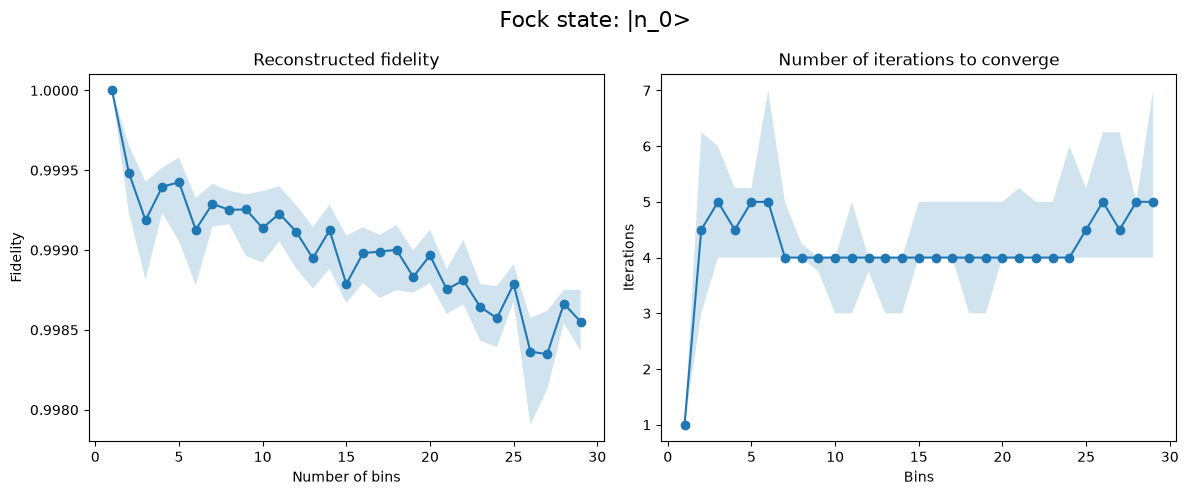

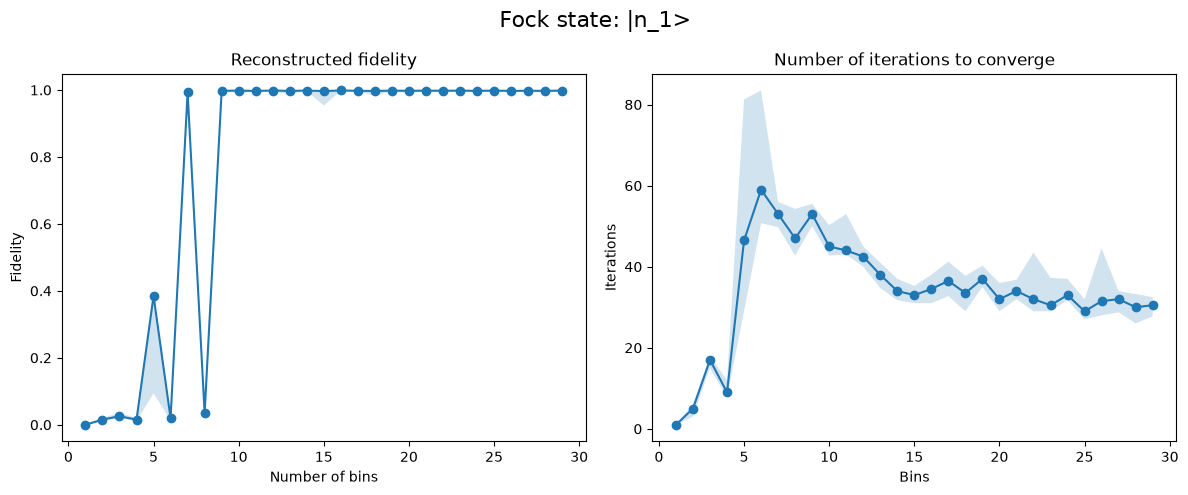

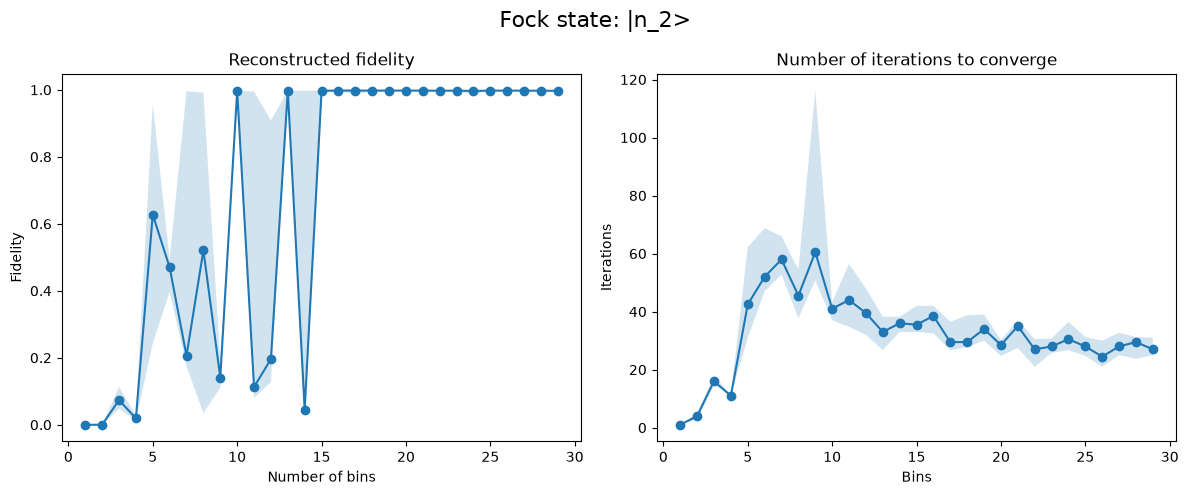

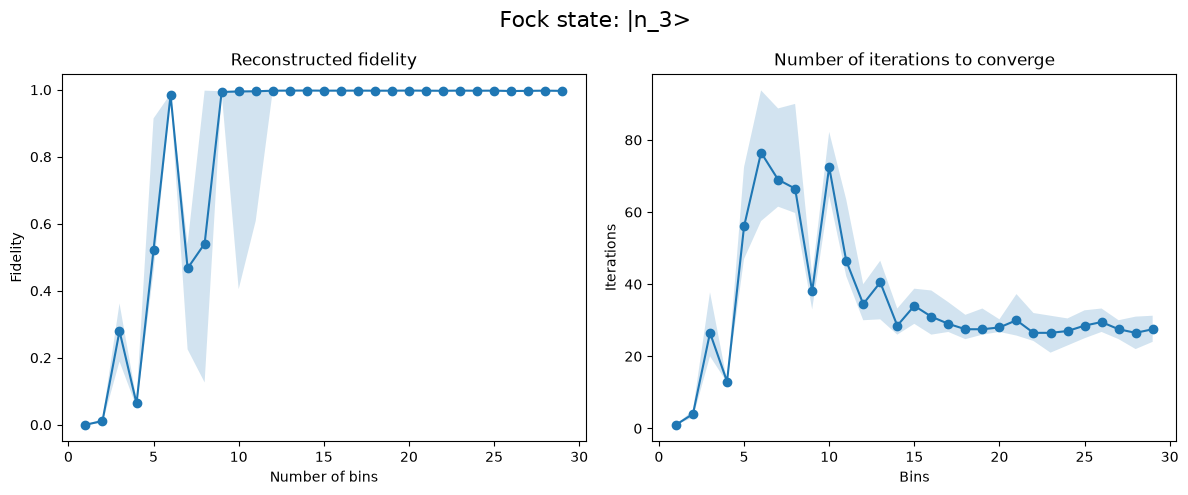

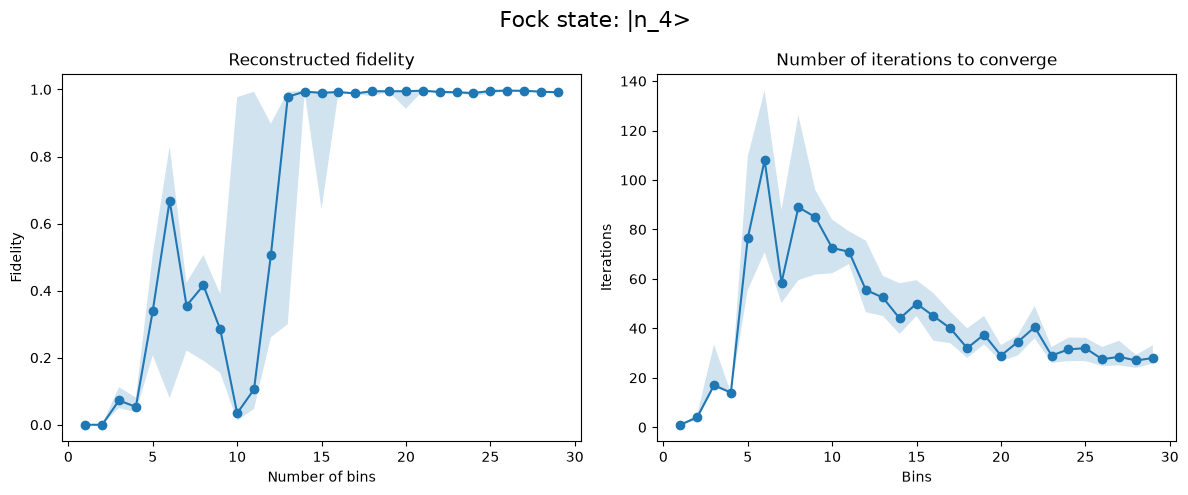

In [17]:
## Fock state data

fock_group = results_20runs["bins"]["Fock"]
n_bins_values = results_20runs["n_bins_values"][:]

for label in sorted(fock_group.keys()):
    state_group = fock_group[label]
    fidelity = state_group["fidelity"][:]      # shape: (n_repeats, n_bins)
    iterations = state_group["iterations"][:]  # shape: (n_repeats, n_bins)

    fid_median = np.median(fidelity, axis=0)
    fid_25 = np.percentile(fidelity, 25, axis=0)
    fid_75 = np.percentile(fidelity, 75, axis=0)
    iter_median = np.median(iterations, axis=0)
    iter_25 = np.percentile(iterations, 25, axis=0)
    iter_75 = np.percentile(iterations, 75, axis=0)

    # One figure per Fock state
    fig, (ax_fid, ax_iter) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    ax_fid.plot(n_bins_values, fid_median, marker="o")
    ax_fid.fill_between(n_bins_values, fid_25, fid_75, alpha=0.2)
    ax_iter.plot(n_bins_values, iter_median, marker="o")
    ax_iter.fill_between(n_bins_values, iter_25, iter_75, alpha=0.2)

    ax_fid.set_xlabel("Number of bins")
    ax_fid.set_ylabel("Fidelity")
    ax_fid.set_title("Reconstructed fidelity")

    ax_iter.set_xlabel("Bins")
    ax_iter.set_ylabel("Iterations")
    ax_iter.set_title("Number of iterations to converge")

    fig.suptitle(fr"Fock state: |{label}>", fontsize=16)
    fig.tight_layout()
    plt.show()


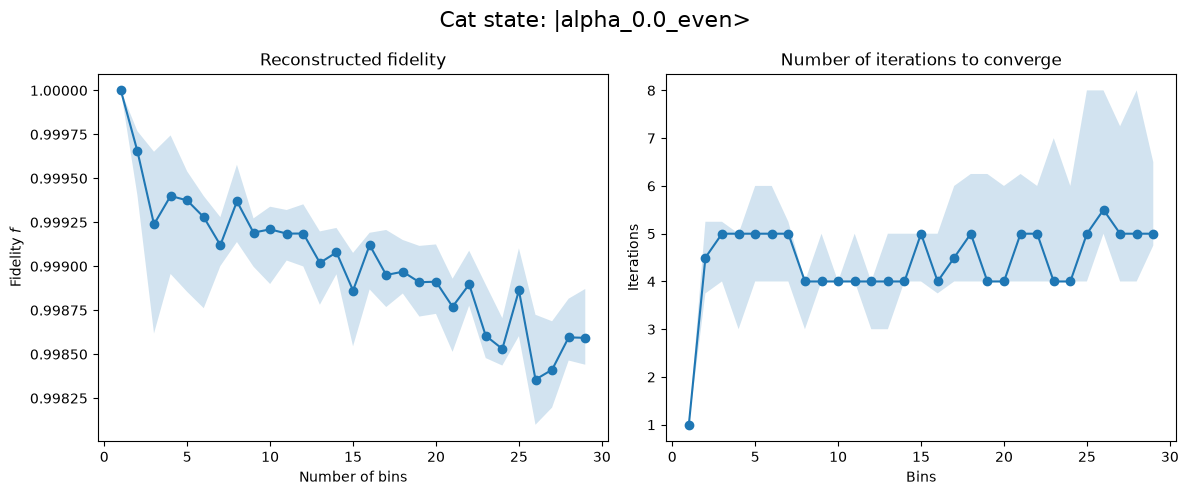

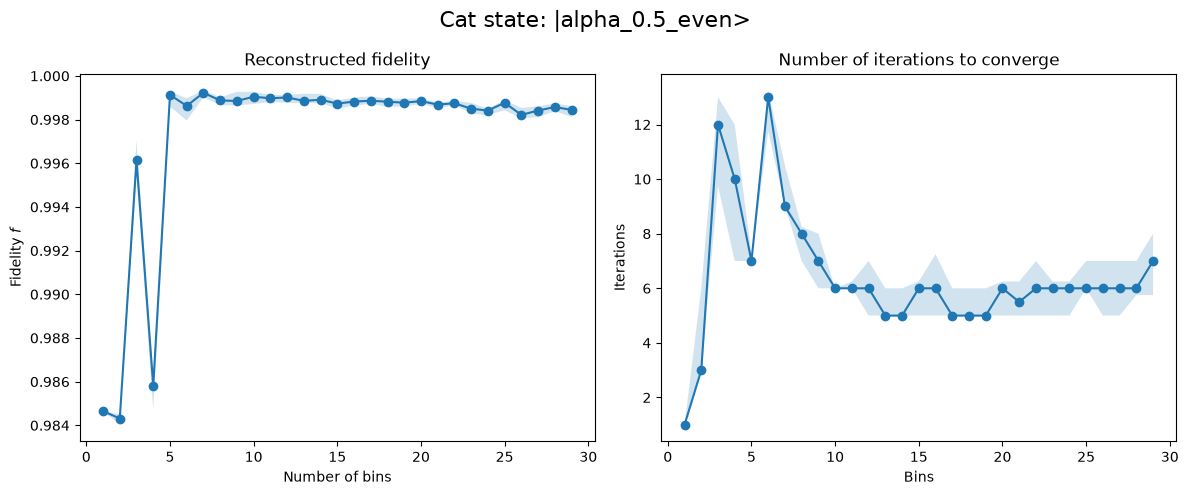

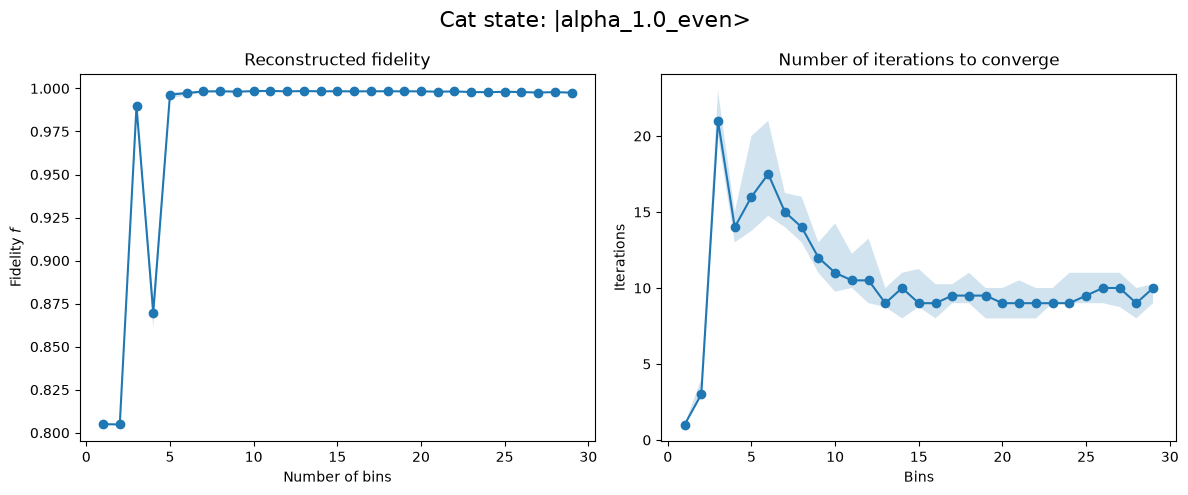

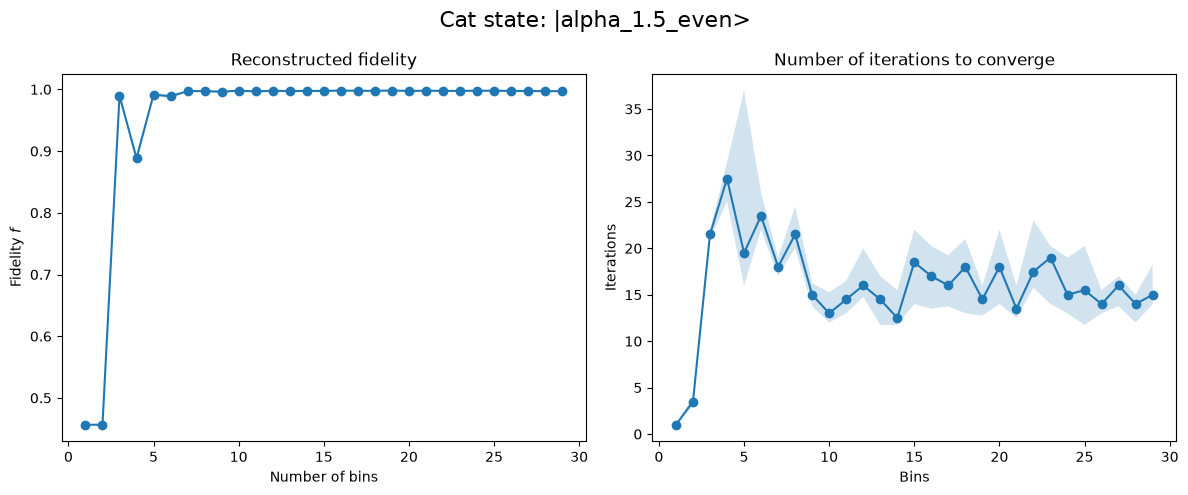

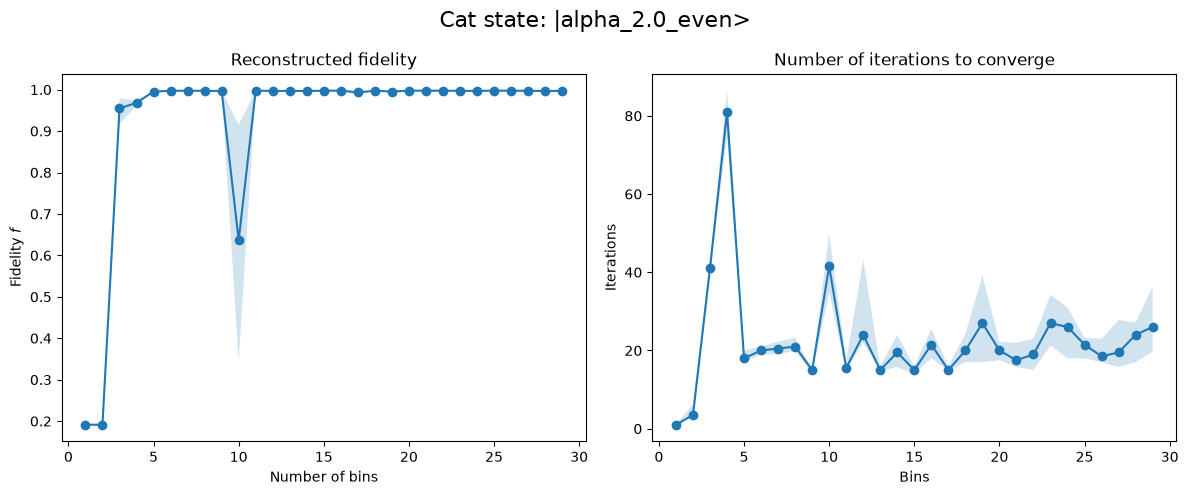

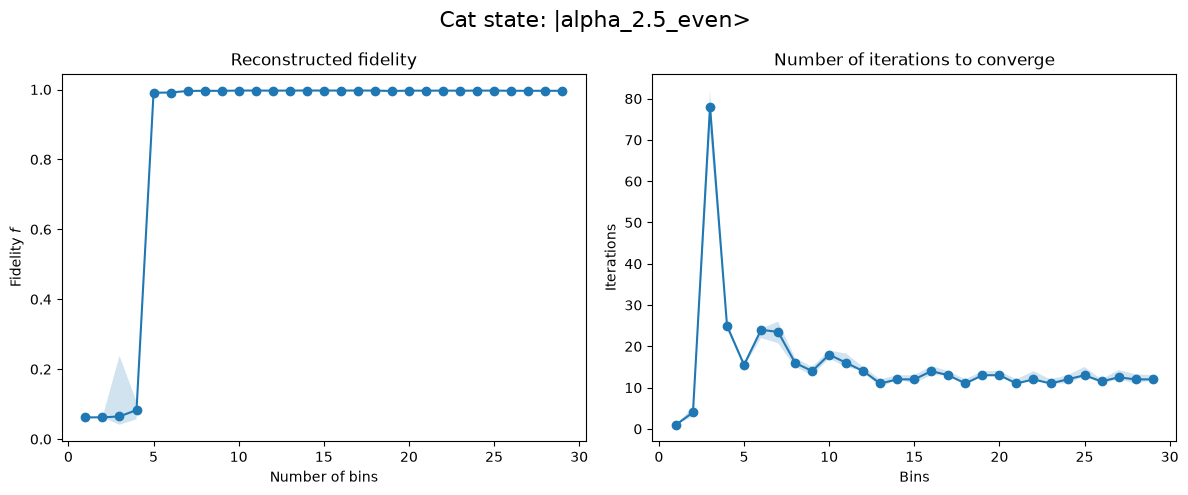

In [15]:
## Cat state data

cat_group = results_20runs["bins"]["cat"]
n_bins_values = results_20runs["n_bins_values"][:]

for label in sorted(cat_group.keys()):
    state_group = cat_group[label]
    fidelity = state_group["fidelity"][:]      # shape: (n_repeats, n_bins)
    iterations = state_group["iterations"][:]  # shape: (n_repeats, n_bins)

    fid_median = np.median(fidelity, axis=0)
    fid_25 = np.percentile(fidelity, 25, axis=0)
    fid_75 = np.percentile(fidelity, 75, axis=0)
    iter_median = np.median(iterations, axis=0)
    iter_25 = np.percentile(iterations, 25, axis=0)
    iter_75 = np.percentile(iterations, 75, axis=0)

    # One figure per Cat state
    fig, (ax_fid, ax_iter) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    ax_fid.plot(n_bins_values, fid_median, marker="o")
    ax_fid.fill_between(n_bins_values, fid_25, fid_75, alpha=0.2)
    ax_iter.plot(n_bins_values, iter_median, marker="o")
    ax_iter.fill_between(n_bins_values, iter_25, iter_75, alpha=0.2)

    ax_fid.set_xlabel("Number of bins")
    ax_fid.set_ylabel(r"Fidelity $f$")
    ax_fid.set_title("Reconstructed fidelity")

    ax_iter.set_xlabel("Bins")
    ax_iter.set_ylabel("Iterations")
    ax_iter.set_title("Number of iterations to converge")

    fig.suptitle(fr"Cat state: |{label}>", fontsize=16)
    fig.tight_layout()
    plt.show()


# Samples analysis

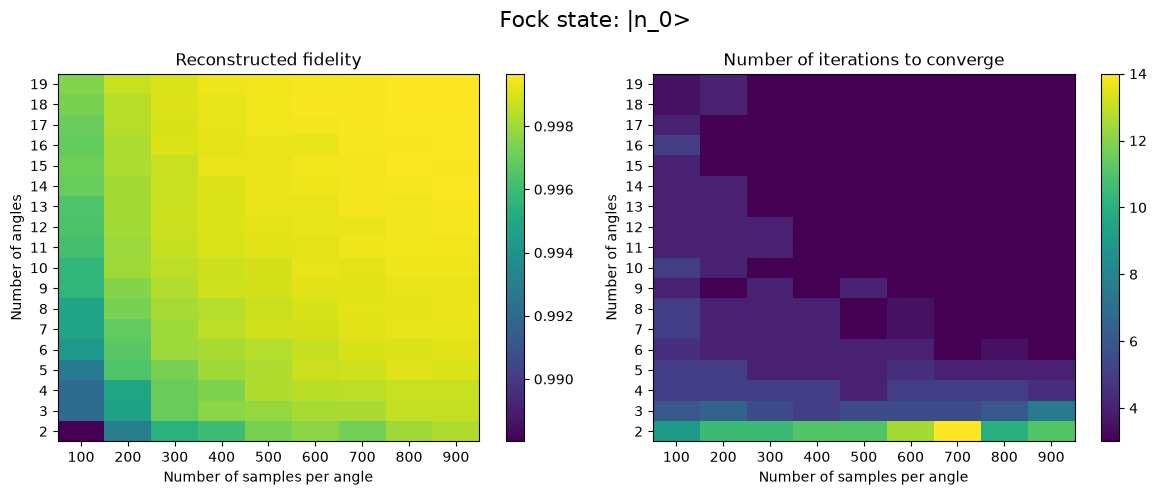

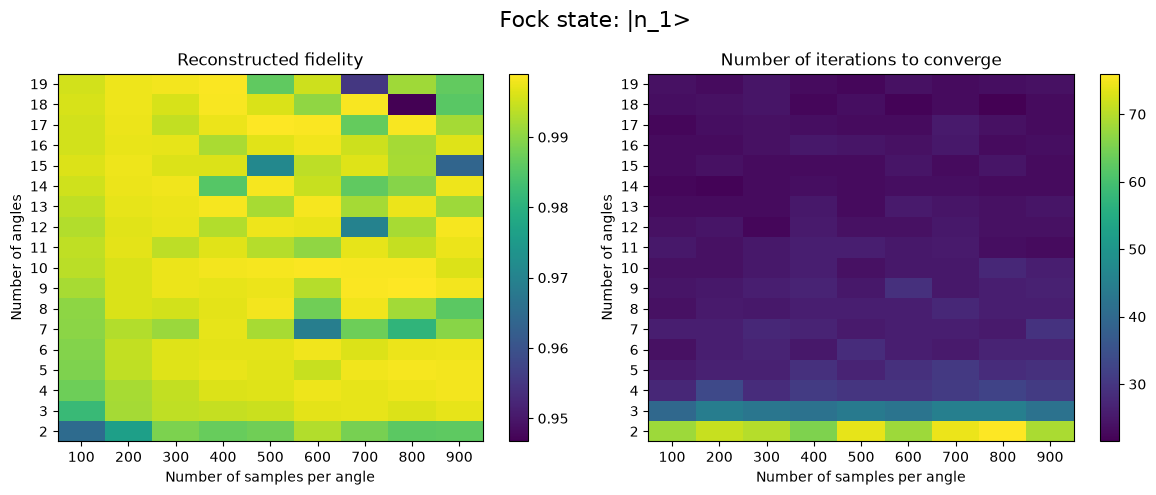

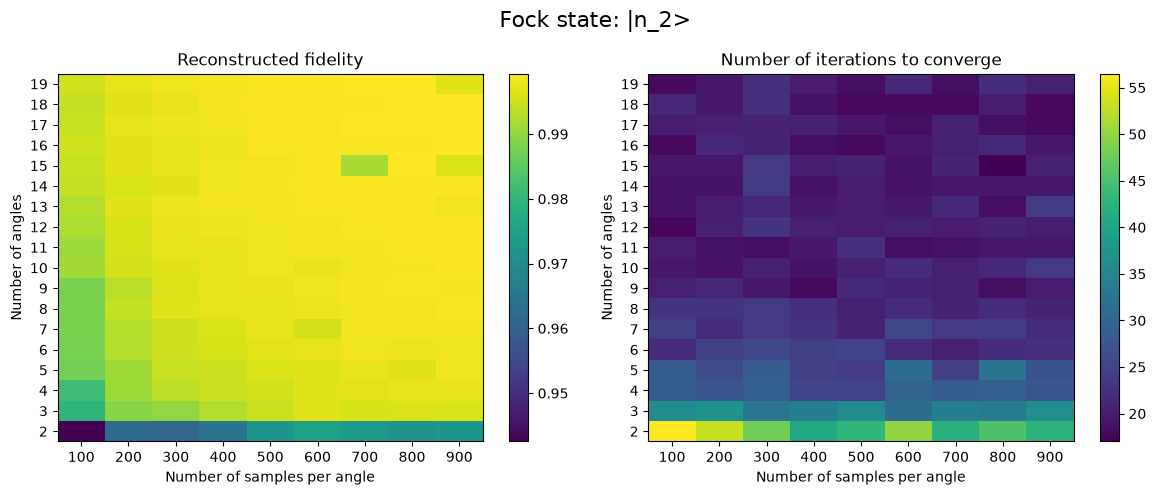

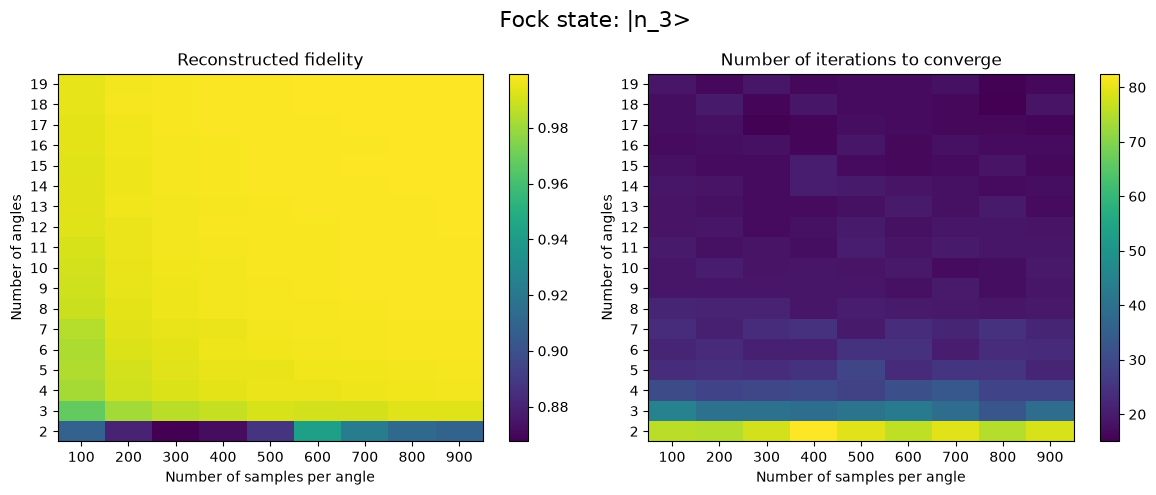

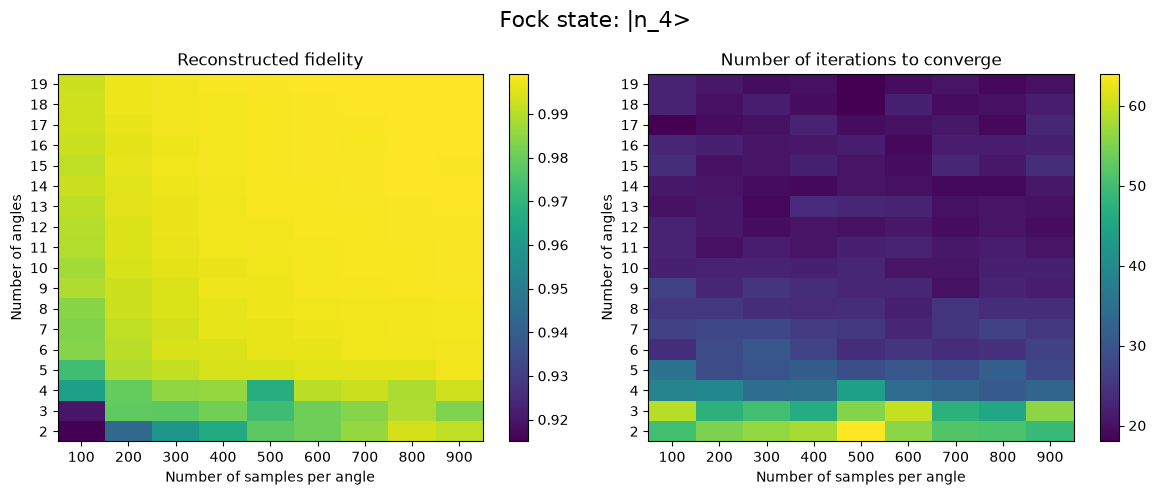

In [18]:
# Fock state data
fock_group = results_20runs["samples"]["Fock"]
n_angles_values = results_20runs["n_angles_values"][:]
n_samples_values = results_20runs["n_samples_values"][:]
# Configs are ordered as (n_angles, n_samples) with n_samples varying fastest
grid_shape = (len(n_angles_values), len(n_samples_values))

for label in sorted(fock_group.keys()):
    state_group = fock_group[label]
    fidelity = state_group["fidelity"][:]      # shape: (n_repeats, n_configs)
    iterations = state_group["iterations"][:]  # shape: (n_repeats, n_configs)

    fid_grid = np.median(fidelity, axis=0).reshape(grid_shape)
    iter_grid = np.median(iterations, axis=0).reshape(grid_shape)

    # One figure per Fock state: heatmaps over (n_angles, n_samples)
    fig, (ax_fid, ax_iter) = plt.subplots(1, 2, figsize=(12, 5))

    im_fid = ax_fid.imshow(fid_grid, aspect="auto", origin="lower", cmap="viridis")
    ax_fid.set_xticks(range(len(n_samples_values)), n_samples_values)
    ax_fid.set_yticks(range(len(n_angles_values)), n_angles_values)
    ax_fid.set_xlabel("Number of samples per angle")
    ax_fid.set_ylabel("Number of angles")
    ax_fid.set_title("Reconstructed fidelity")
    fig.colorbar(im_fid, ax=ax_fid)

    im_iter = ax_iter.imshow(iter_grid, aspect="auto", origin="lower", cmap="viridis")
    ax_iter.set_xticks(range(len(n_samples_values)), n_samples_values)
    ax_iter.set_yticks(range(len(n_angles_values)), n_angles_values)
    ax_iter.set_xlabel("Number of samples per angle")
    ax_iter.set_ylabel("Number of angles")
    ax_iter.set_title("Number of iterations to converge")
    fig.colorbar(im_iter, ax=ax_iter)

    fig.suptitle(fr"Fock state: |{label}>", fontsize=16)
    fig.tight_layout()
    plt.show()

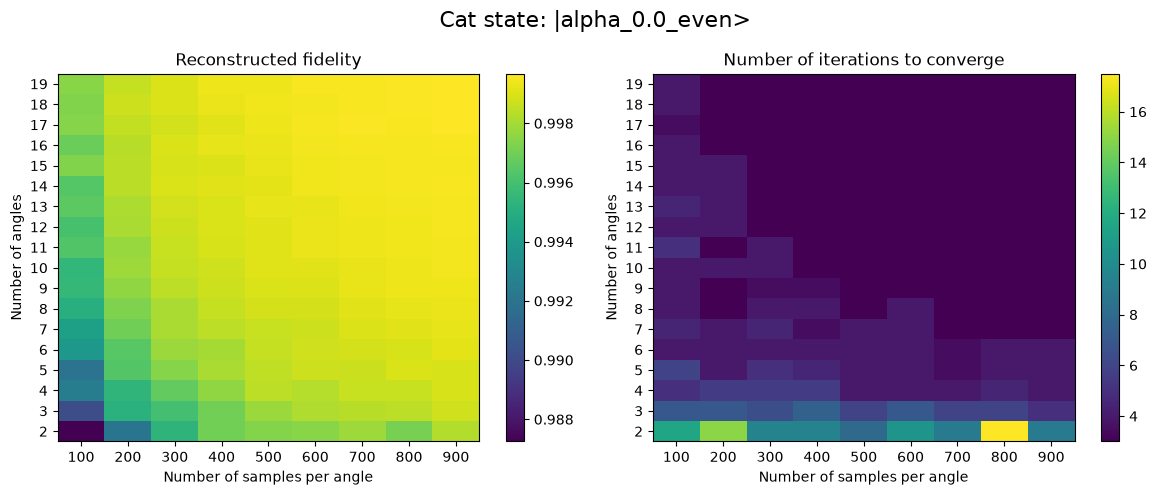

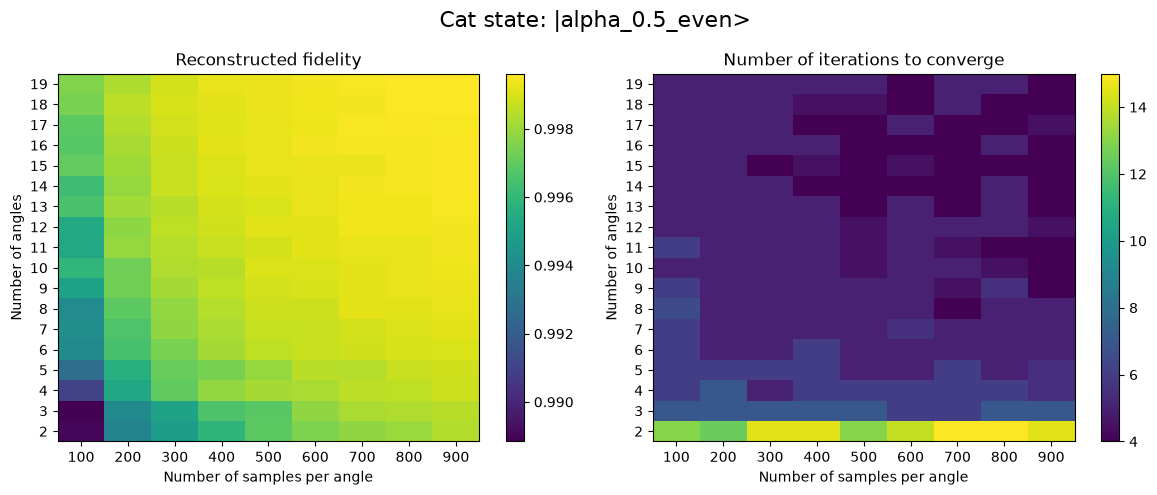

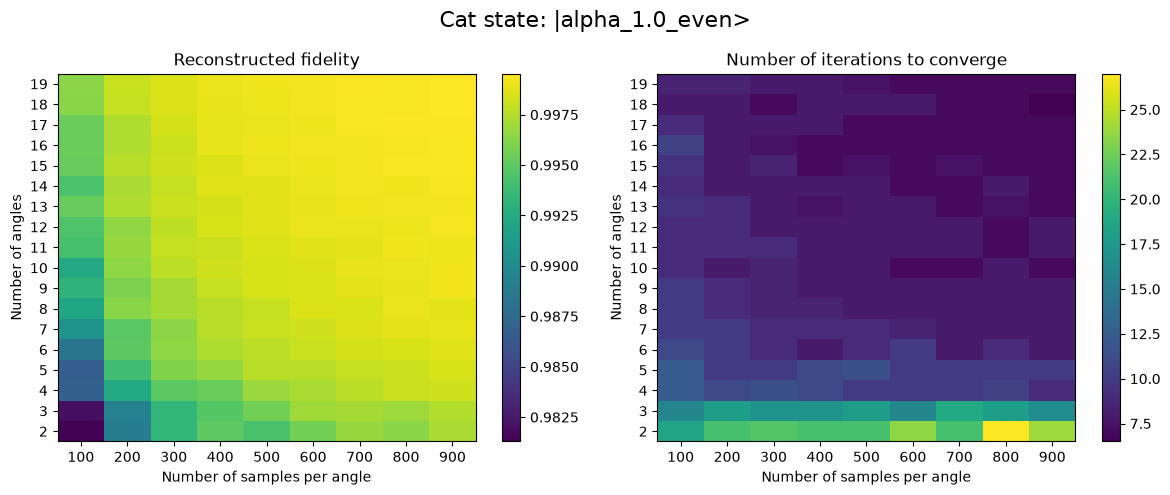

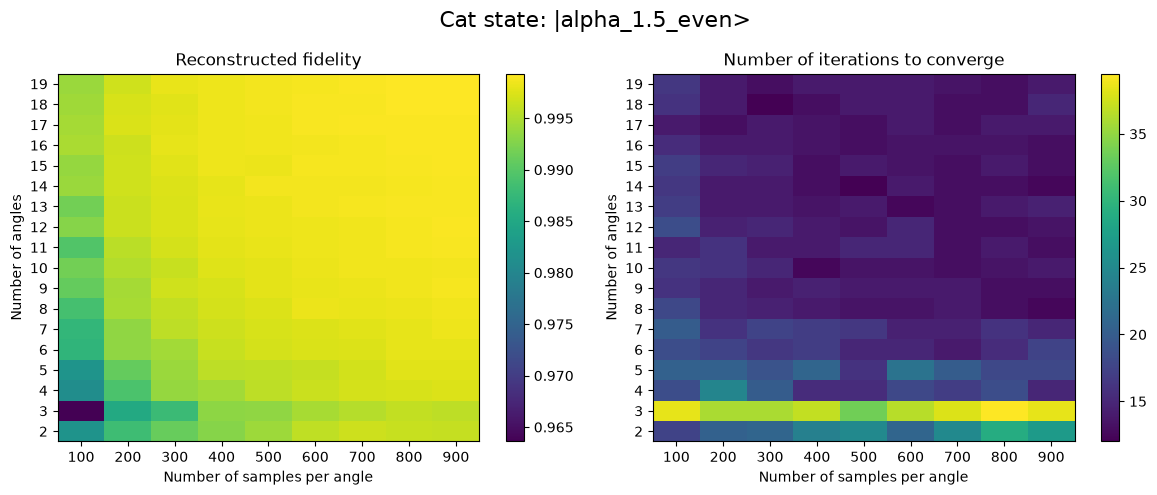

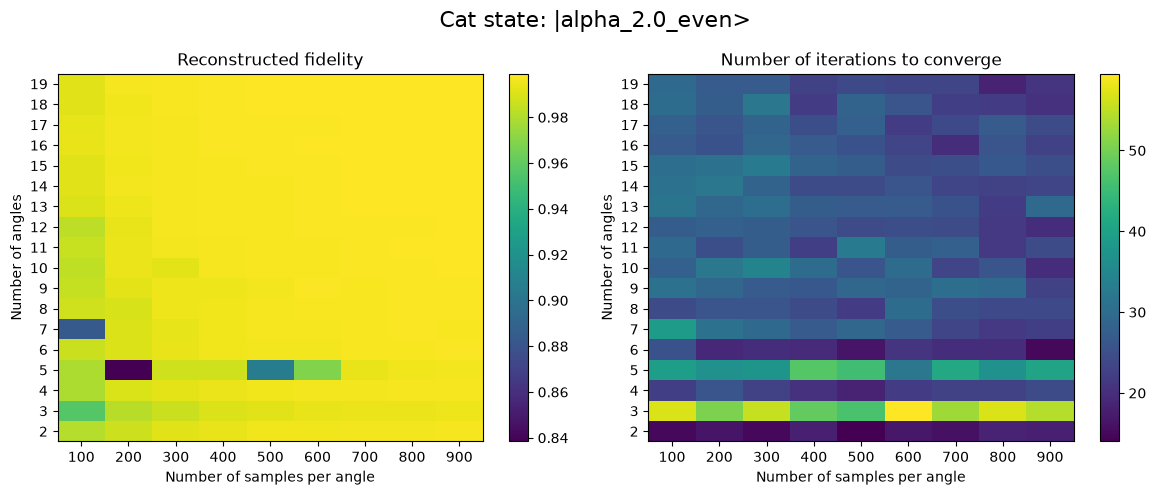

In [19]:
# Cat state data
cat_group = results_20runs["samples"]["cat"]
n_angles_values = results_20runs["n_angles_values"][:]
n_samples_values = results_20runs["n_samples_values"][:]
# Configs are ordered as (n_angles, n_samples) with n_samples varying fastest
grid_shape = (len(n_angles_values), len(n_samples_values))

for label in sorted(cat_group.keys()):
    state_group = cat_group[label]
    fidelity = state_group["fidelity"][:]      # shape: (n_repeats, n_configs)
    iterations = state_group["iterations"][:]  # shape: (n_repeats, n_configs)

    fid_grid = np.median(fidelity, axis=0).reshape(grid_shape)
    iter_grid = np.median(iterations, axis=0).reshape(grid_shape)

    # One figure per Fock state: heatmaps over (n_angles, n_samples)
    fig, (ax_fid, ax_iter) = plt.subplots(1, 2, figsize=(12, 5))

    im_fid = ax_fid.imshow(fid_grid, aspect="auto", origin="lower", cmap="viridis")
    ax_fid.set_xticks(range(len(n_samples_values)), n_samples_values)
    ax_fid.set_yticks(range(len(n_angles_values)), n_angles_values)
    ax_fid.set_xlabel("Number of samples per angle")
    ax_fid.set_ylabel("Number of angles")
    ax_fid.set_title("Reconstructed fidelity")
    fig.colorbar(im_fid, ax=ax_fid)

    im_iter = ax_iter.imshow(iter_grid, aspect="auto", origin="lower", cmap="viridis")
    ax_iter.set_xticks(range(len(n_samples_values)), n_samples_values)
    ax_iter.set_yticks(range(len(n_angles_values)), n_angles_values)
    ax_iter.set_xlabel("Number of samples per angle")
    ax_iter.set_ylabel("Number of angles")
    ax_iter.set_title("Number of iterations to converge")
    fig.colorbar(im_iter, ax=ax_iter)

    fig.suptitle(fr"Cat state: |{label}>", fontsize=16)
    fig.tight_layout()
    plt.show()